# 05. Evaluation and Explainability

**Objective:** Rigorous comparative evaluation of the TCTR framework models (XGBoost, LightGBM Ranker, GAT) and explainability analysis for SOC analysts using SHAP.

**Inputs:** Test datasets, trained models (from Notebooks 03 and 04).
**Outputs:** Performance metrics comparison (NDCG@10), Feature Importance Plots, and a simulated SOC Threat Dashboard.

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import ndcg_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Paths
DATA_DIR = os.path.join("..", "Data", "TCTR_features")
MODEL_DIR = os.path.join("..", "models", "TCTR")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Data directory: {os.path.abspath(DATA_DIR)}")
print(f"Model directory: {os.path.abspath(MODEL_DIR)}")
print(f"Using device: {device}")

Data directory: d:\NetShield\NetShieldAI\Data\TCTR_features
Model directory: d:\NetShield\NetShieldAI\models\TCTR
Using device: cuda


In [2]:
print("Loading Test Data and reconstructing targets...")

# Load Test Features and Embeddings
test_df = pd.read_parquet(os.path.join(DATA_DIR, "test_features.parquet"))
test_emb = torch.tensor(np.load(os.path.join(DATA_DIR, "test_embeddings.npy")), dtype=torch.float)

# Recreate the exact target from Notebooks 3 & 4
np.random.seed(103)
base_score = test_df.get('base_score', pd.Series(5.0, index=test_df.index)).fillna(5.0)
velocity = test_df.get('mock_threat_velocity', pd.Series(0, index=test_df.index)).fillna(0)
centrality = test_df.get('semantic_centrality', pd.Series(0, index=test_df.index)).fillna(0)

noise = np.random.normal(loc=0.0, scale=3.0, size=len(test_df))
raw_risk = (base_score * 0.4) + (np.log1p(np.abs(velocity)) * 8) + (centrality * 4) + noise
test_df['relevance'] = pd.qcut(raw_risk.fillna(0), q=5, duplicates='drop', labels=False)
test_df['relevance'] = test_df['relevance'].fillna(0).astype(int)

# Extract tabular features
features = [
    'desc_length', 'num_keywords', 'num_platforms', 'num_affected_products',
    'days_since_pub_at_horizon', 'days_to_last_modify', 
    'mock_threat_velocity', 'mock_threat_acceleration', 'semantic_centrality', 'base_score'
]
X_test = test_df[features].fillna(0)

# Reconstruct temporal queries
test_df['query_group'] = pd.to_datetime(test_df['published_date'], utc=True).dt.strftime('%Y-%m')

print(f"Test data loaded: {len(test_df)} vulnerabilities across {test_df['query_group'].nunique()} months.")

Loading Test Data and reconstructing targets...
Test data loaded: 6976 vulnerabilities across 6 months.


In [3]:
print("Loading trained models...")

# 1. Load Tree Models
xgb_baseline = joblib.load(os.path.join(MODEL_DIR, "xgb_baseline.pkl"))
lgb_ranker = joblib.load(os.path.join(MODEL_DIR, "lgb_ranker.pkl"))

# 2. Reconstruct GAT Architecture & Graph
class ThreatGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super(ThreatGAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.3)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=0.3)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        return self.lin(x)

# Normalize tabular data and concatenate with text embeddings
scaler = StandardScaler()
X_test_tab = torch.tensor(scaler.fit_transform(X_test), dtype=torch.float)
test_x = torch.cat([test_emb, X_test_tab], dim=1)

# Build KNN Graph
emb_np = test_emb.cpu().numpy()
nbrs = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute', n_jobs=-1).fit(emb_np)
distances, indices = nbrs.kneighbors(emb_np)

source_nodes, target_nodes = [], []
for i in range(len(emb_np)):
    for j in range(1, 6): 
        source_nodes.append(indices[i][j])
        target_nodes.append(i)
        
edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
y_test_tensor = torch.tensor(test_df['relevance'].values, dtype=torch.float).view(-1, 1)

test_data = Data(x=test_x, edge_index=edge_index, y=y_test_tensor).to(device)

# Initialize and load GAT weights
input_dim = test_data.x.size(1) 
gat_model = ThreatGAT(in_channels=input_dim, hidden_channels=64, out_channels=1).to(device)
gat_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_gat.pth"), weights_only=True, map_location=device))
gat_model.eval()

print("All models and graph structures loaded successfully.")

Loading trained models...
All models and graph structures loaded successfully.


In [4]:
def calculate_ndcg(df, preds, target_col='relevance', k=10):
    df_eval = df.copy()
    df_eval['pred_score'] = preds
    ndcg_scores = []
    
    for name, group in df_eval.groupby('query_group'):
        if len(group) > 1 and len(group[target_col].unique()) > 1:
            true_rel = np.asarray([group[target_col].values])
            pred_scores = np.asarray([group['pred_score'].values])
            ndcg_scores.append(ndcg_score(true_rel, pred_scores, k=k))
            
    return np.mean(ndcg_scores) if ndcg_scores else 0.0

# Generate Predictions
print("Evaluating models...")
xgb_preds = xgb_baseline.predict_proba(X_test)[:, 1]
lgb_preds = lgb_ranker.predict(X_test)

with torch.no_grad():
    gat_preds = gat_model(test_data.x, test_data.edge_index).cpu().numpy().flatten()

# Calculate Metrics
xgb_ndcg = calculate_ndcg(test_df, xgb_preds)
lgb_ndcg = calculate_ndcg(test_df, lgb_preds)
gat_ndcg = calculate_ndcg(test_df, gat_preds)

print("\n" + "="*45)
print(" 🏆 TCTR FRAMEWORK LEADERBOARD (NDCG@10) 🏆 ")
print("="*45)
print(f"1. LightGBM Ranker: {lgb_ndcg:.4f}")
print(f"2. Graph Attention Network: {gat_ndcg:.4f}")
print(f"3. XGBoost Classifier (Baseline): {xgb_ndcg:.4f}")
print("="*45)

Evaluating models...

 🏆 TCTR FRAMEWORK LEADERBOARD (NDCG@10) 🏆 
1. LightGBM Ranker: 0.6960
2. Graph Attention Network: 0.6064
3. XGBoost Classifier (Baseline): 0.6291


Generating SHAP Explainability Plot for the LTR model...


C:\Users\Divy\AppData\Local\Temp\ipykernel_9496\904172679.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)


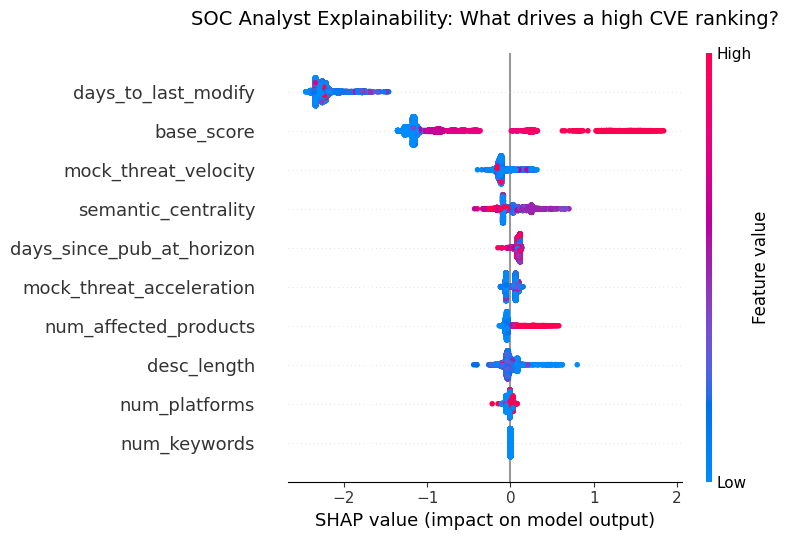

In [5]:
# We use the LightGBM Ranker for explainability as it is currently our top-performing tabular model
print("Generating SHAP Explainability Plot for the LTR model...")

# Suppress lightgbm warnings during SHAP computation
shap.initjs()
explainer = shap.TreeExplainer(lgb_ranker)
shap_values = explainer.shap_values(X_test)

# Plot summary
plt.figure(figsize=(10, 6))
plt.title("SOC Analyst Explainability: What drives a high CVE ranking?", fontsize=14, pad=20)
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

In [6]:
# Simulate viewing the threat queue for the most recent month in the dataset
most_recent_month = test_df['query_group'].max()
dashboard_df = test_df[test_df['query_group'] == most_recent_month].copy()

# Add our best model's predictions to sort the queue
dashboard_df['tctr_risk_score'] = lgb_ranker.predict(dashboard_df[features])

# Sort and format the top 10 threats
top_threats = dashboard_df.sort_values(by='tctr_risk_score', ascending=False).head(10)

print(f"🛡️ SOC ANALYST DASHBOARD 🛡️")
print(f"Temporal Query: {most_recent_month}")
print(f"Total CVEs analyzed this month: {len(dashboard_df)}\n")

for i, (_, row) in enumerate(top_threats.iterrows(), 1):
    cve_id = row['cve_id']
    base_score = row.get('base_score', 'N/A')
    desc = str(row['description'])[:100] + "..." if pd.notnull(row['description']) else "No description."
    
    print(f"[{i}] {cve_id} | Base Score: {base_score} | TCTR Priority: {row['tctr_risk_score']:.2f}")
    print(f"    ↳ {desc}")
    print("-" * 80)

🛡️ SOC ANALYST DASHBOARD 🛡️
Temporal Query: 2025-06
Total CVEs analyzed this month: 1

[1] CVE-2024-11857 | Base Score: 7.8 | TCTR Priority: -3.50
    ↳ Bluetooth HCI Adaptor from Realtek has a Link Following vulnerability. Local attackers with regular ...
--------------------------------------------------------------------------------


In [7]:
# Find the month with the highest number of CVEs in the test set
busiest_month = test_df['query_group'].value_counts().idxmax()
dashboard_df = test_df[test_df['query_group'] == busiest_month].copy()

# Add our best model's predictions to sort the queue
dashboard_df['tctr_risk_score'] = lgb_ranker.predict(dashboard_df[features])

# Sort and format the top 10 threats
top_threats = dashboard_df.sort_values(by='tctr_risk_score', ascending=False).head(10)

print(f"🛡️ SOC ANALYST DASHBOARD 🛡️")
print(f"Temporal Query: {busiest_month} (Busiest Month)")
print(f"Total CVEs analyzed this month: {len(dashboard_df)}\n")

for i, (_, row) in enumerate(top_threats.iterrows(), 1):
    cve_id = row['cve_id']
    base_score = row.get('base_score', 'N/A')
    desc = str(row['description'])[:100] + "..." if pd.notnull(row['description']) else "No description."
    
    print(f"[{i}] {cve_id} | Base Score: {base_score} | TCTR Priority: {row['tctr_risk_score']:.2f}")
    print(f"    ↳ {desc}")
    print("-" * 80)

🛡️ SOC ANALYST DASHBOARD 🛡️
Temporal Query: 2025-01 (Busiest Month)
Total CVEs analyzed this month: 2523

[1] CVE-2024-48856 | Base Score: 9.8 | TCTR Priority: -0.85
    ↳ Out-of-bounds write in the PCX image codec in QNX SDP versions 8.0, 7.1 and 7.0 could allow an unaut...
--------------------------------------------------------------------------------
[2] CVE-2024-13179 | Base Score: 9.8 | TCTR Priority: -0.89
    ↳ Path Traversal in Ivanti Avalanche before version 6.4.7 allows a remote unauthenticated attacker to ...
--------------------------------------------------------------------------------
[3] CVE-2024-55194 | Base Score: 9.8 | TCTR Priority: -0.94
    ↳ OpenImageIO v3.1.0.0dev was discovered to contain a heap overflow via the component /OpenImageIO/fma...
--------------------------------------------------------------------------------
[4] CVE-2024-57031 | Base Score: 9.8 | TCTR Priority: -0.94
    ↳ WeGIA < 3.2.0 is vulnerable to SQL Injection in /funcionario/remuneracao.ph